In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons

!pip install hdbscan

### Dataset Generation and Visualization

To effectively compare DBSCAN and HDBSCAN, we'll create a synthetic dataset that includes clusters of varying densities, non-globular shapes, and some noise points. This will allow us to observe how each algorithm handles these complexities.

### DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a popular clustering algorithm that groups together points that are closely packed together, marking as outliers points that lie alone in low-density regions. It requires two main parameters: `eps` (ε) and `min_samples` (MinPts).

- `eps`: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
- `min_samples`: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.

Let's apply DBSCAN to our synthetic dataset and visualize the results.

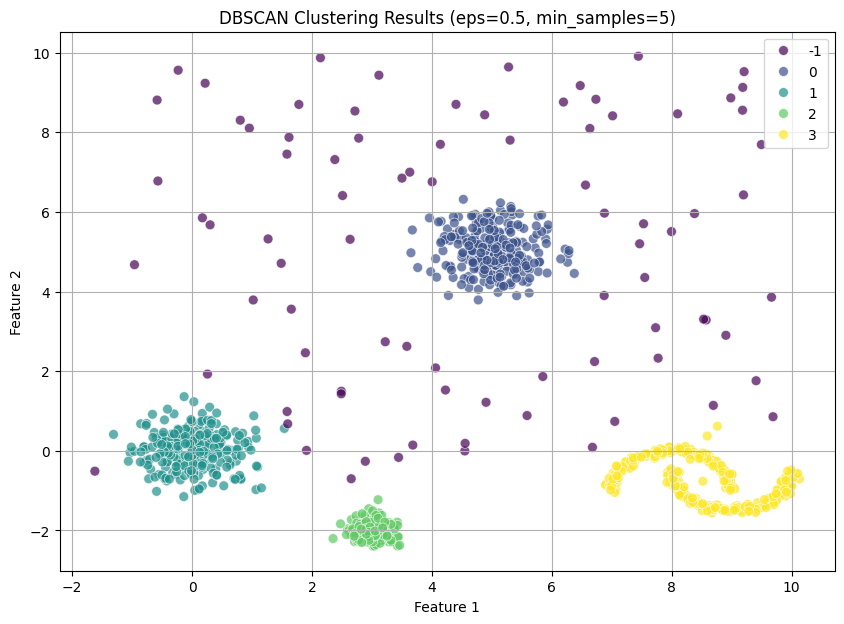

DBSCAN - Estimated number of clusters: 4
DBSCAN - Estimated number of noise points: 85


In [7]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=dbscan_labels, palette='viridis', legend='full', s=50, alpha=0.7)
plt.title('DBSCAN Clustering Results (eps=0.5, min_samples=5)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)
print(f'DBSCAN - Estimated number of clusters: {n_clusters_dbscan}')
print(f'DBSCAN - Estimated number of noise points: {n_noise_dbscan}')

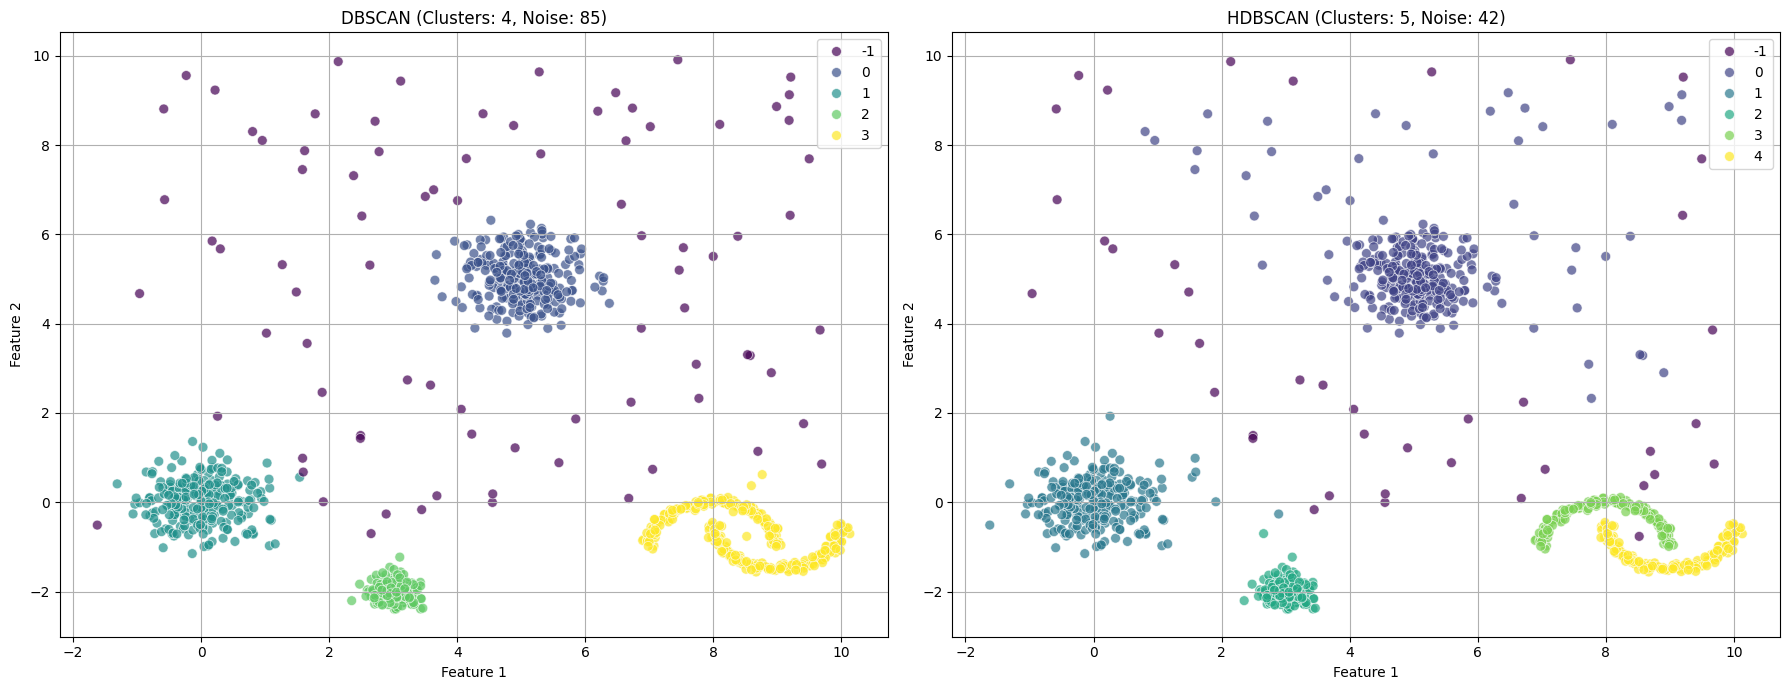

In [8]:
plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=dbscan_labels, palette='viridis', legend='full', s=50, alpha=0.7)
plt.title(f'DBSCAN (Clusters: {n_clusters_dbscan}, Noise: {n_noise_dbscan})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=hdbscan_labels, palette='viridis', legend='full', s=50, alpha=0.7)
plt.title(f'HDBSCAN (Clusters: {n_clusters_hdbscan}, Noise: {n_noise_hdbscan})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

plt.tight_layout()
plt.show()

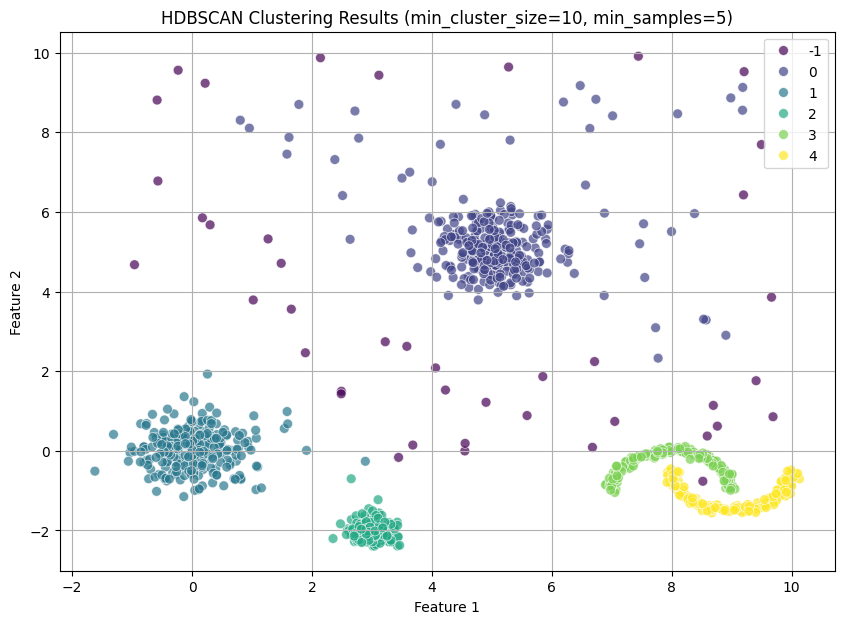

HDBSCAN - Estimated number of clusters: 5
HDBSCAN - Estimated number of noise points: 42


In [9]:
import hdbscan

hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, prediction_data=True)
hdbscan_labels = hdbscan_clusterer.fit_predict(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=hdbscan_labels, palette='viridis', legend='full', s=50, alpha=0.7)
plt.title('HDBSCAN Clustering Results (min_cluster_size=10, min_samples=5)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

n_clusters_hdbscan = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise_hdbscan = list(hdbscan_labels).count(-1)
print(f'HDBSCAN - Estimated number of clusters: {n_clusters_hdbscan}')
print(f'HDBSCAN - Estimated number of noise points: {n_noise_hdbscan}')

/tmp/ipykernel_2111/234902911.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=X[:, 0], y=X[:, 1], palette='viridis', legend='full', s=50, alpha=0.7)


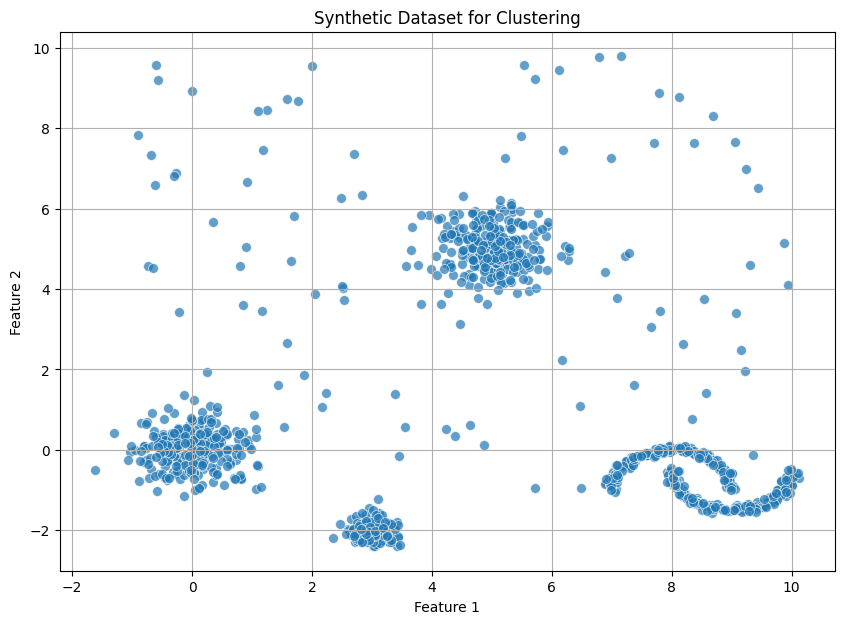

In [10]:
X1, y1 = make_blobs(n_samples=500, centers=[[0, 0], [5, 5]], cluster_std=[0.5, 0.5], random_state=42)

X2, y2 = make_blobs(n_samples=200, centers=[[3, -2]], cluster_std=0.2, random_state=42)

X3, y3 = make_moons(n_samples=300, noise=0.05, random_state=42)
X3[:, 0] += 8
X3[:, 1] -= 1

X_noise = np.random.uniform(low=-1, high=10, size=(100, 2))

X = np.vstack([X1, X2, X3, X_noise])
y = np.hstack([y1, y2, y3, np.full(X_noise.shape[0], -1)])

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], palette='viridis', legend='full', s=50, alpha=0.7)
plt.title('Synthetic Dataset for Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()